In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
games = pd.read_csv('vgsales.csv')

In [4]:
games.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


#### Proporção de vendas globais por gênero da Nintendo

In [7]:
games_nintendo = games[games['Publisher']=='Nintendo']
games_nintendo.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [12]:
generos = games_nintendo.drop(['Name', 'Platform', 'Year', 'Publisher'], axis=1)
generos = generos.groupby('Genre').sum()
generos.head()

,Rank,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Genre,,,,,,
Action,359543,63.49,29.02,29.24,6.48,128.18
Adventure,193705,17.72,7.66,9.01,1.28,35.71
Fighting,47056,27.10,8.64,14.94,2.65,53.35
Misc,523309,61.98,51.62,55.25,11.78,180.67
Platform,245890,220.14,85.21,102.36,19.47,427.21


In [15]:
generos = generos.sort_values(by='Global_Sales', ascending=False)
porcentagens = generos['Global_Sales']/generos['Global_Sales'].sum()*100
porcentagens.head()

Genre
Platform        23.912435
Role-Playing    15.946848
Sports          12.202781
Misc            10.112731
Racing           8.468789
Name: Global_Sales, dtype: float64

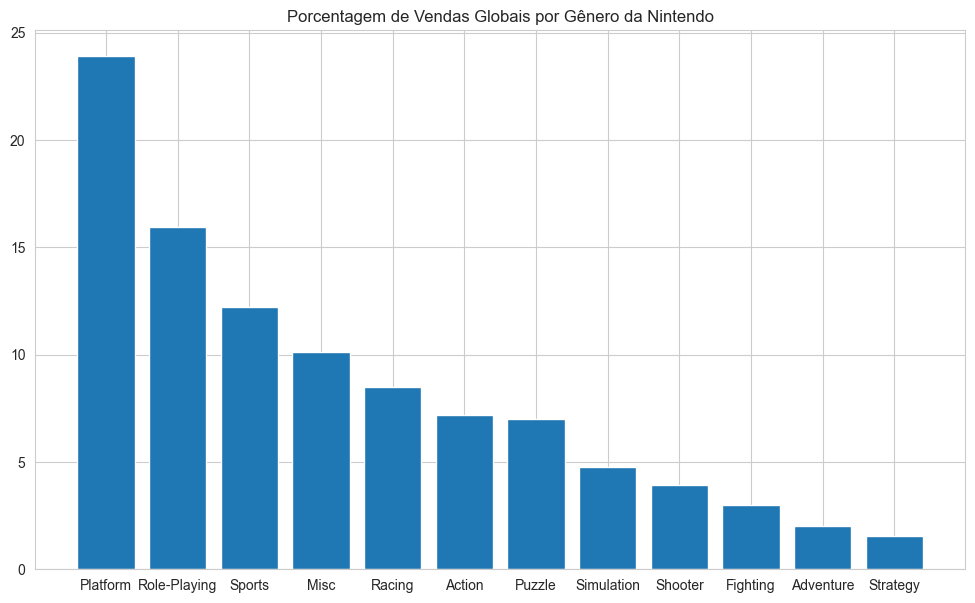

In [20]:
plt.figure(figsize=(12, 7))
plt.title("Porcentagem de Vendas Globais por Gênero da Nintendo")
plt.bar(generos.index, porcentagens)
sns.set_style('whitegrid')
plt.show()

#### Proporção de quantidade de jogos por plataforma a partir de 2015

In [21]:
games.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [24]:
games_2015fw = games[games['Year'] >= 2015]
games_2015fw.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
33,34,Call of Duty: Black Ops 3,PS4,2015.0,Shooter,Activision,5.77,5.81,0.35,2.31,14.24
77,78,FIFA 16,PS4,2015.0,Sports,Electronic Arts,1.11,6.06,0.06,1.26,8.49
92,93,Star Wars Battlefront (2015),PS4,2015.0,Shooter,Electronic Arts,2.93,3.29,0.22,1.23,7.67
101,102,Call of Duty: Black Ops 3,XOne,2015.0,Shooter,Activision,4.52,2.09,0.01,0.67,7.30
109,110,Fallout 4,PS4,2015.0,Role-Playing,Bethesda Softworks,2.47,3.15,0.24,1.10,6.96


In [30]:
proporcao = games_2015fw.groupby('Platform').count()
proporcao = proporcao.sort_values(by='Rank', ascending=False)
proporcao.head()

,Rank,Name,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Platform,,,,,,,,,,
PS4,245,245,245,245,245,245,245,245,245,245
PSV,175,175,175,175,173,175,175,175,175,175
XOne,133,133,133,133,133,133,133,133,133,133
3DS,121,121,121,121,121,121,121,121,121,121
PS3,106,106,106,106,106,106,106,106,106,106


In [32]:
porcentagens = proporcao['Rank']/proporcao['Rank'].sum()*100
porcentagens.head()

Platform
PS4     25.467775
PSV     18.191268
XOne    13.825364
3DS     12.577963
PS3     11.018711
Name: Rank, dtype: float64

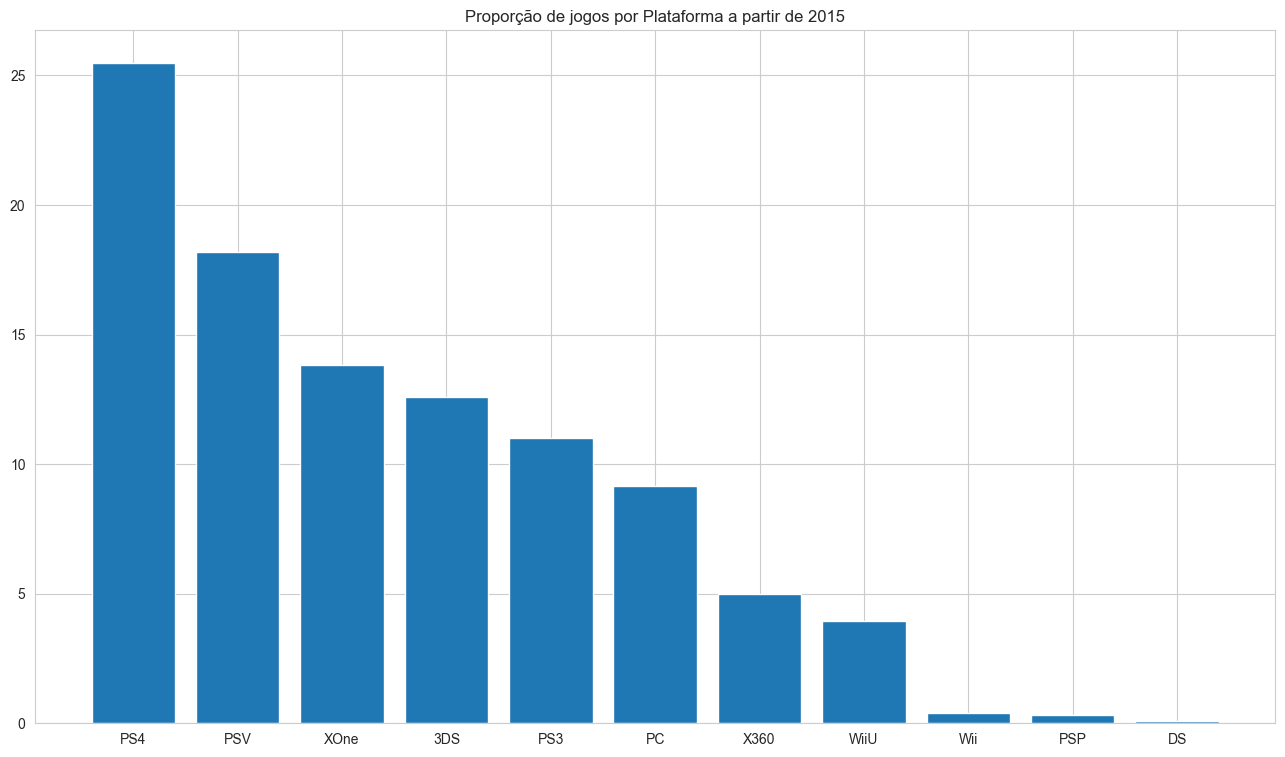

In [33]:
sns.set_style('whitegrid')
plt.figure(figsize=(16,9))
plt.title("Proporção de jogos por Plataforma a partir de 2015")
plt.bar(proporcao.index, porcentagens)
plt.show()